# Review Scores Analysis

Analysis of code review findings and ratings from various AI review tools.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import numpy as np

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Load the data
df = pd.read_csv('data/review_scores.csv')

# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Display basic info
print(f"Total findings: {len(df)}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nDate range: {df['timestamp'].min()} to {df['timestamp'].max()}")

df.head()

Total findings: 139

Columns: ['timestamp', 'pr_url', 'finding_id', 'tool_name', 'finding_type', 'finding_url', 'evaluator_id', 'master_rating', 'master_reasoning', 'finding_summary', 'detection_latency_ms', 'false_positive_link']

Date range: 2026-06-09 10:03:42.468000+00:00 to 2026-06-12 16:50:46.845000+00:00


,timestamp,pr_url,finding_id,tool_name,finding_type,finding_url,evaluator_id,master_rating,master_reasoning,finding_summary,detection_latency_ms,false_positive_link
0,2026-06-09 10:52:27.073000+00:00,https://github.com/abapify/openadt/pull/78,scan:80304544164:0,main,code_scan,https://github.com/abapify/openadt/actions/run...,kilo/minimax/minimax-m3,1,main CI: Java tests skipped is expected for a ...,Java tests skipped,51000,NaN
1,2026-06-09 10:52:27.073000+00:00,https://github.com/abapify/openadt/pull/78,scan:80304542309:0,submit-maven,code_scan,https://github.com/abapify/openadt/actions/run...,kilo/minimax/minimax-m3,1,submit-maven: pre-existing Node.js 20 deprecat...,Node.js 20 actions are deprecated. The followi...,25000,NaN
2,2026-06-09 10:52:27.073000+00:00,https://github.com/abapify/openadt/pull/78,scan:80304542309:1,submit-maven,code_scan,https://github.com/abapify/openadt/actions/run...,kilo/minimax/minimax-m3,0,submit-maven log: Snapshot successfully create...,Snapshot successfully created at 2026-06-09T10...,25000,NaN
3,2026-06-09 10:52:27.073000+00:00,https://github.com/abapify/openadt/pull/78,scan:80304542309:2,submit-maven,code_scan,https://github.com/abapify/openadt/actions/run...,kilo/minimax/minimax-m3,0,submit-maven log: maven manifest JSON dump - p...,"{ ""manifests"": { ""openadt-bootstrap"": { ""resol...",25000,NaN
4,2026-06-09 10:52:27.073000+00:00,https://github.com/abapify/openadt/pull/78,scan:80304542309:3,submit-maven,code_scan,https://github.com/abapify/openadt/actions/run...,kilo/minimax/minimax-m3,0,submit-maven log: Submitting snapshot - pure C...,Submitting snapshot...,25000,NaN


## Master Rating Distribution

Rating scale: 0-5 (higher = more valuable finding)

Rating Distribution:
master_rating
0    28
1    30
2    33
3    14
4    19
5    15
Name: count, dtype: int64


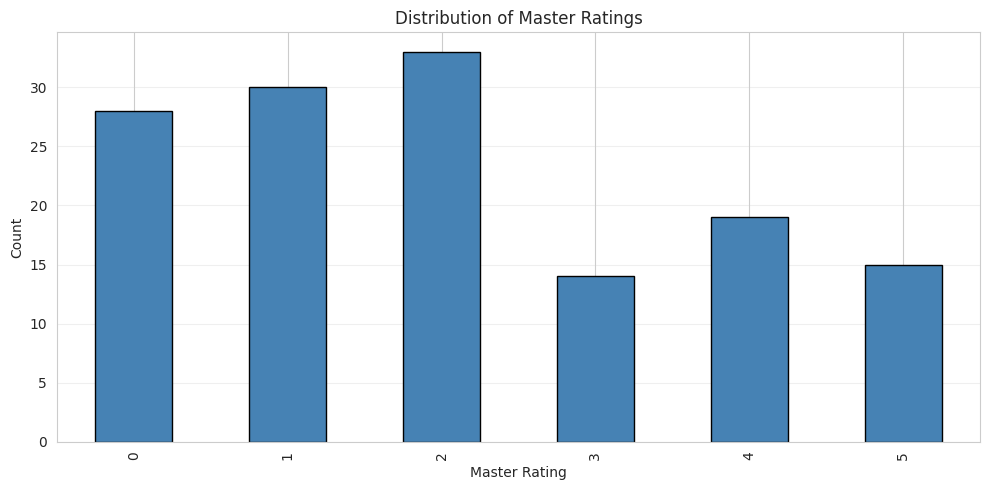

In [3]:
# Rating distribution
rating_counts = df['master_rating'].value_counts().sort_index()
print("Rating Distribution:")
print(rating_counts)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
rating_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Master Rating')
ax.set_ylabel('Count')
ax.set_title('Distribution of Master Ratings')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Tool Performance Analysis

In [4]:
# Analyze by tool name
tool_stats = df.groupby('tool_name').agg({
    'master_rating': ['count', 'mean', 'median'],
    'detection_latency_ms': 'mean'
}).round(2)

tool_stats.columns = ['count', 'avg_rating', 'median_rating', 'avg_latency_ms']
tool_stats = tool_stats.sort_values('avg_rating', ascending=False)

print("Tool Performance:")
print(tool_stats)

Tool Performance:
                                 count  avg_rating  median_rating  \
tool_name                                                           
kilo-code-bot[bot]                   1        5.00            5.0   
codeant-ai[bot]                     10        4.20            5.0   
coderabbitai[bot]                    5        4.00            4.0   
github-advanced-security[bot]        1        4.00            4.0   
gemini-code-assist[bot]             13        3.46            3.0   
amazon-q-developer[bot]              5        3.00            3.0   
codescene-delta-analysis[bot]       28        2.57            2.0   
greptile-apps[bot]                   4        2.50            2.5   
main                                 3        2.00            1.0   
ThePlenkov                           3        2.00            2.0   
github-code-quality[bot]            35        1.40            1.0   
submit-maven                        20        0.75            0.0   
Analyze (csharp)

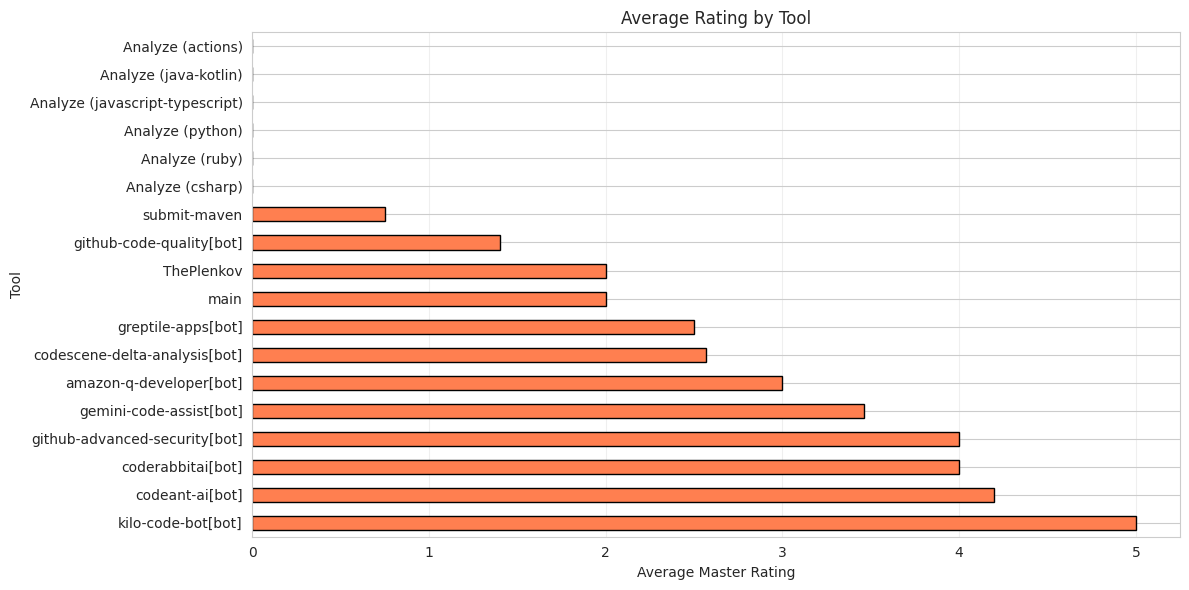

In [5]:
# Plot average rating by tool
fig, ax = plt.subplots(figsize=(12, 6))
tool_stats['avg_rating'].plot(kind='barh', ax=ax, color='coral', edgecolor='black')
ax.set_xlabel('Average Master Rating')
ax.set_ylabel('Tool')
ax.set_title('Average Rating by Tool')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Finding Type Analysis

In [6]:
# Analyze by finding type
type_stats = df.groupby('finding_type').agg({
    'master_rating': ['count', 'mean', 'median']
}).round(2)

type_stats.columns = ['count', 'avg_rating', 'median_rating']
type_stats = type_stats.sort_values('count', ascending=False)

print("Finding Type Statistics:")
print(type_stats)

Finding Type Statistics:
              count  avg_rating  median_rating
finding_type                                  
code_review     105        2.55            2.0
code_scan        34        0.62            0.0


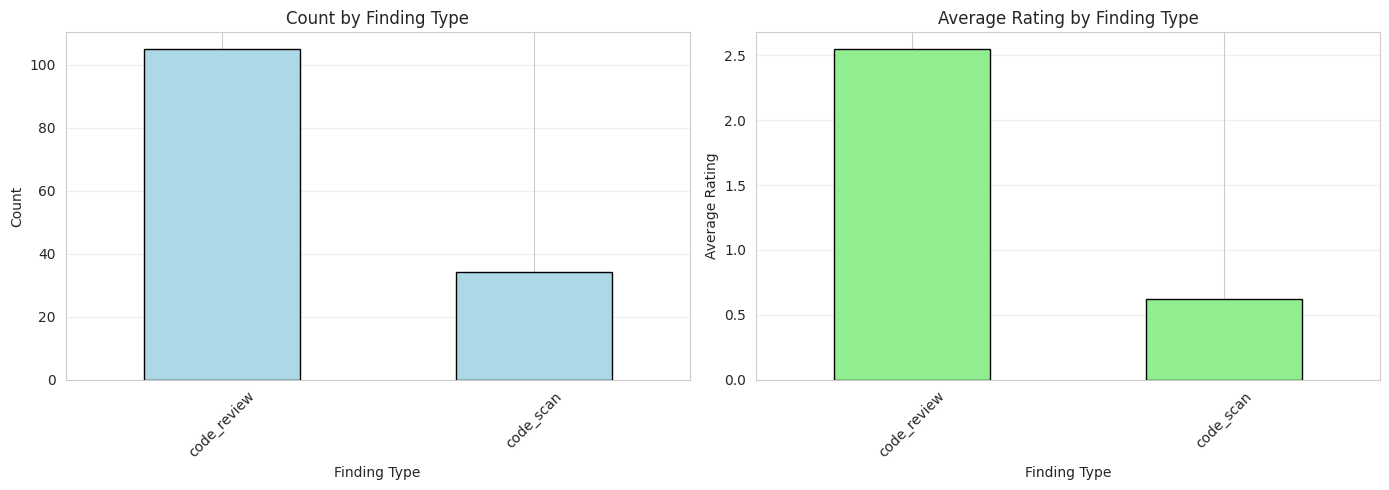

In [7]:
# Plot finding type distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Count by type
type_stats['count'].plot(kind='bar', ax=ax1, color='lightblue', edgecolor='black')
ax1.set_xlabel('Finding Type')
ax1.set_ylabel('Count')
ax1.set_title('Count by Finding Type')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Average rating by type
type_stats['avg_rating'].plot(kind='bar', ax=ax2, color='lightgreen', edgecolor='black')
ax2.set_xlabel('Finding Type')
ax2.set_ylabel('Average Rating')
ax2.set_title('Average Rating by Finding Type')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## High-Value Findings (Rating >= 4)

In [8]:
# Filter high-value findings
high_value = df[df['master_rating'] >= 4].sort_values('master_rating', ascending=False)

print(f"High-value findings (rating >= 4): {len(high_value)} out of {len(df)} ({100*len(high_value)/len(df):.1f}%)")
print(f"\nTop 20 high-value findings:")

for idx, row in high_value.head(20).iterrows():
    print(f"\nRating: {row['master_rating']} | Tool: {row['tool_name']} | Type: {row['finding_type']}")
    print(f"Summary: {row['finding_summary'][:100]}...")
    print(f"Reasoning: {row['master_reasoning'][:100]}...")

High-value findings (rating >= 4): 34 out of 139 (24.5%)

Top 20 high-value findings:

Rating: 5 | Tool: gemini-code-assist[bot] | Type: code_review
Summary: ![high](https://www.gstatic.com/codereviewagent/high-priority.svg) If `onEndpointFailure()` throws …...
Reasoning: gemini — onEndpointFailure rejection escapes forwardToBackend. Real bug (hung JSON-RPC), I fixed it ...

Rating: 5 | Tool: codeant-ai[bot] | Type: code_review
Summary: **Suggestion:** The reconnect callback is awaited without its own error handling; if the callback r…...
Reasoning: codeant — same onEndpointFailure rejection issue. Duplicate of 3379166368 from a different reviewer....

Rating: 5 | Tool: codeant-ai[bot] | Type: code_review
Summary: **🟠 Architect Review — HIGH** The `/harvest` CLI forwards `harvest:pr` directly to `harvest-thread…...
Reasoning: Correct HIGH-severity finding: /harvest pr/batch needed OWNER REPO resolution. Fixed in 184b79e via ...

Rating: 5 | Tool: gemini-code-assist[bot] | Type: code_re

## Detection Latency Analysis

In [9]:
# Latency statistics
latency_stats = df['detection_latency_ms'].describe()
print("Detection Latency Statistics (ms):")
print(latency_stats)

# Convert to seconds for readability
print(f"\nAverage detection time: {latency_stats['mean']/1000:.2f} seconds")
print(f"Median detection time: {latency_stats['50%']/1000:.2f} seconds")

Detection Latency Statistics (ms):
count       139.000000
mean      29964.028777
std       85403.425420
min           0.000000
25%           0.000000
50%           0.000000
75%       25000.000000
max      908000.000000
Name: detection_latency_ms, dtype: float64

Average detection time: 29.96 seconds
Median detection time: 0.00 seconds


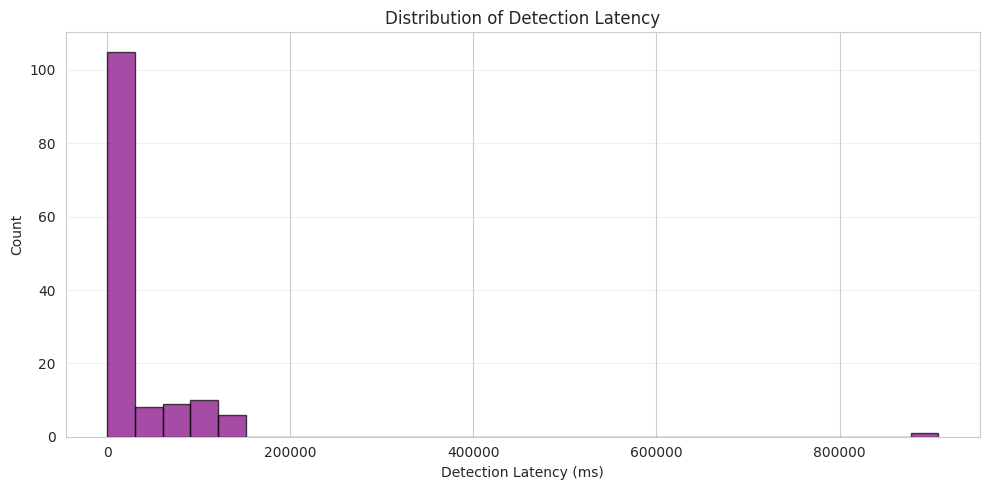

In [10]:
# Plot latency distribution
fig, ax = plt.subplots(figsize=(10, 5))
df['detection_latency_ms'].plot(kind='hist', bins=30, ax=ax, color='purple', edgecolor='black', alpha=0.7)
ax.set_xlabel('Detection Latency (ms)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Detection Latency')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## PR Analysis

In [11]:
# Extract PR numbers
df['pr_number'] = df['pr_url'].str.extract(r'/pull/(\d+)').astype(int)

# PR statistics
pr_stats = df.groupby('pr_number').agg({
    'master_rating': ['count', 'mean', 'median'],
    'finding_type': lambda x: x.mode()[0] if not x.mode().empty else 'N/A'
}).round(2)

pr_stats.columns = ['total_findings', 'avg_rating', 'median_rating', 'most_common_type']
pr_stats = pr_stats.sort_values('avg_rating', ascending=False)

print("PR Statistics:")
print(pr_stats)

PR Statistics:
           total_findings  avg_rating  median_rating most_common_type
pr_number                                                            
88                      7        4.43            4.0      code_review
77                     21        3.43            5.0      code_review
83                     19        3.21            3.0      code_review
89                     81        1.52            1.0      code_review
78                     11        0.18            0.0        code_scan


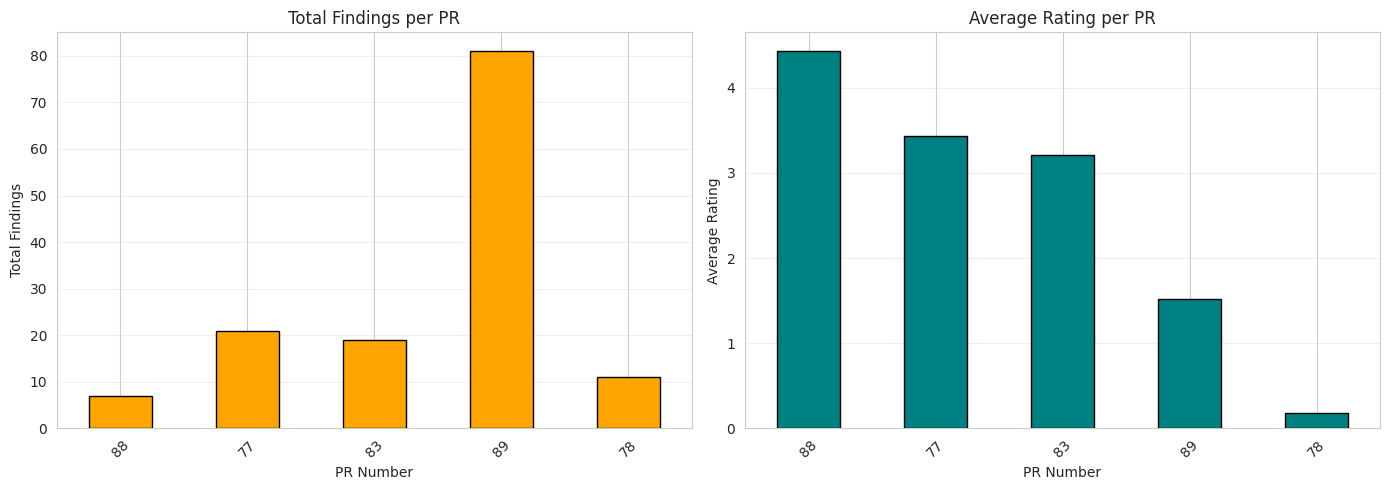

In [12]:
# Plot PR comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Total findings per PR
pr_stats['total_findings'].plot(kind='bar', ax=ax1, color='orange', edgecolor='black')
ax1.set_xlabel('PR Number')
ax1.set_ylabel('Total Findings')
ax1.set_title('Total Findings per PR')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Average rating per PR
pr_stats['avg_rating'].plot(kind='bar', ax=ax2, color='teal', edgecolor='black')
ax2.set_xlabel('PR Number')
ax2.set_ylabel('Average Rating')
ax2.set_title('Average Rating per PR')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Evaluator Analysis

In [13]:
# Detailed Reviewer Analysis
reviewer_details = df[df['finding_type'] == 'code_review'].groupby(['evaluator_id', 'tool_name']).agg({
    'master_rating': ['count', 'mean', 'median', 'std'],
    'finding_summary': lambda x: list(x)[:3]  # Sample findings
}).round(2)

reviewer_details.columns = ['count', 'avg_rating', 'median_rating', 'std_rating', 'sample_findings']
reviewer_details = reviewer_details.sort_values('avg_rating', ascending=False)

print("DETAILED REVIEWER ANALYSIS (code_review only)")
print("=" * 70)
for (evaluator, tool), stats in reviewer_details.iterrows():
    print(f"\n{evaluator} ({tool}):")
    print(f"  Total Reviews: {stats['count']}")
    print(f"  Avg Rating: {stats['avg_rating']:.2f}")
    print(f"  Median Rating: {stats['median_rating']:.2f}")
    print(f"  Std Dev: {stats['std_rating']:.2f}")
    print(f"  Sample Findings:")
    for i, finding in enumerate(stats['sample_findings'], 1):
        print(f"    {i}. {finding[:80]}...")

# Reviewer performance over time
df['date'] = df['timestamp'].dt.date
reviewer_timeline = df[df['finding_type'] == 'code_review'].groupby(['evaluator_id', 'date']).agg({
    'master_rating': 'mean'
}).reset_index()

print(f"\n\nREVIEWER ACTIVITY OVER TIME")
print("=" * 70)
for evaluator in df[df['finding_type'] == 'code_review']['evaluator_id'].unique():
    evaluator_data = reviewer_timeline[reviewer_timeline['evaluator_id'] == evaluator]
    if len(evaluator_data) > 0:
        print(f"\n{evaluator}:")
        print(f"  Active Days: {len(evaluator_data)}")
        print(f"  Date Range: {evaluator_data['date'].min()} to {evaluator_data['date'].max()}")
        print(f"  Trend: {evaluator_data['master_rating'].iloc[-1]:.2f} (latest) vs {evaluator_data['master_rating'].iloc[0]:.2f} (earliest)")

DETAILED REVIEWER ANALYSIS (code_review only)

kilo/minimax-minimax-m3 (amazon-q-developer[bot]):
  Total Reviews: 1
  Avg Rating: 5.00
  Median Rating: 5.00
  Std Dev: nan
  Sample Findings:
    1. :stop_sign: **Crash Risk**: `archiveDir()` will crash when `listHarvestPaths()` ...

kilo/minimax/minimax-m3 (kilo-code-bot[bot]):
  Total Reviews: 1
  Avg Rating: 5.00
  Median Rating: 5.00
  Std Dev: nan
  Sample Findings:
    1. **CRITICAL:** If `spawn()` throws an exception, `child` is undefined, causing a ...

kilo/minimax-minimax-m3 (gemini-code-assist[bot]):
  Total Reviews: 2
  Avg Rating: 4.50
  Median Rating: 4.50
  Std Dev: 0.71
  Sample Findings:
    1. ![high](https://www.gstatic.com/codereviewagent/high-priority.svg) The `archiveD...
    2. ![medium](https://www.gstatic.com/codereviewagent/medium-priority.svg) The Merma...

kilo/minimax-minimax-m3 (codeant-ai[bot]):
  Total Reviews: 3
  Avg Rating: 4.33
  Median Rating: 4.00
  Std Dev: 0.58
  Sample Findings:
    1. **🟠 Archit

In [14]:
# Analyze by evaluator
evaluator_stats = df.groupby('evaluator_id').agg({
    'master_rating': ['count', 'mean', 'median', 'std']
}).round(2)

evaluator_stats.columns = ['count', 'avg_rating', 'median_rating', 'std_rating']
evaluator_stats = evaluator_stats.sort_values('avg_rating', ascending=False)

print("Evaluator Performance:")
print(evaluator_stats)

Evaluator Performance:
                         count  avg_rating  median_rating  std_rating
evaluator_id                                                         
kilo/minimax-minimax-m3      7        4.43            4.0        0.53
composer-2.5                19        3.21            3.0        0.85
kilo/minimax/minimax-m3     32        2.31            1.0        2.33
haiku                       81        1.52            1.0        1.07


## Correlation Analysis

Correlation Matrix:
                      master_rating  detection_latency_ms  pr_number
master_rating              1.000000             -0.032224  -0.233154
detection_latency_ms      -0.032224              1.000000  -0.026130
pr_number                 -0.233154             -0.026130   1.000000


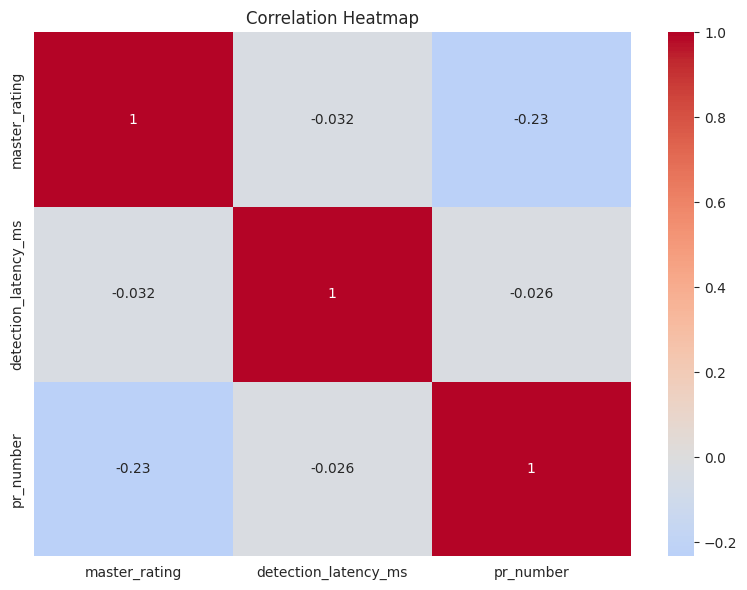

In [15]:
# Create numeric correlations
numeric_df = df[['master_rating', 'detection_latency_ms']].copy()
numeric_df['pr_number'] = df['pr_number']

correlation_matrix = numeric_df.corr()
print("Correlation Matrix:")
print(correlation_matrix)

# Plot correlation heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## Time Series Analysis

In [16]:
# Group by date
df['date'] = df['timestamp'].dt.date
daily_stats = df.groupby('date').agg({
    'master_rating': ['count', 'mean']
}).round(2)

daily_stats.columns = ['count', 'avg_rating']

print("Daily Statistics:")
print(daily_stats)

Daily Statistics:
            count  avg_rating
date                         
2026-06-09     51        2.65
2026-06-10      7        4.43
2026-06-12     81        1.52


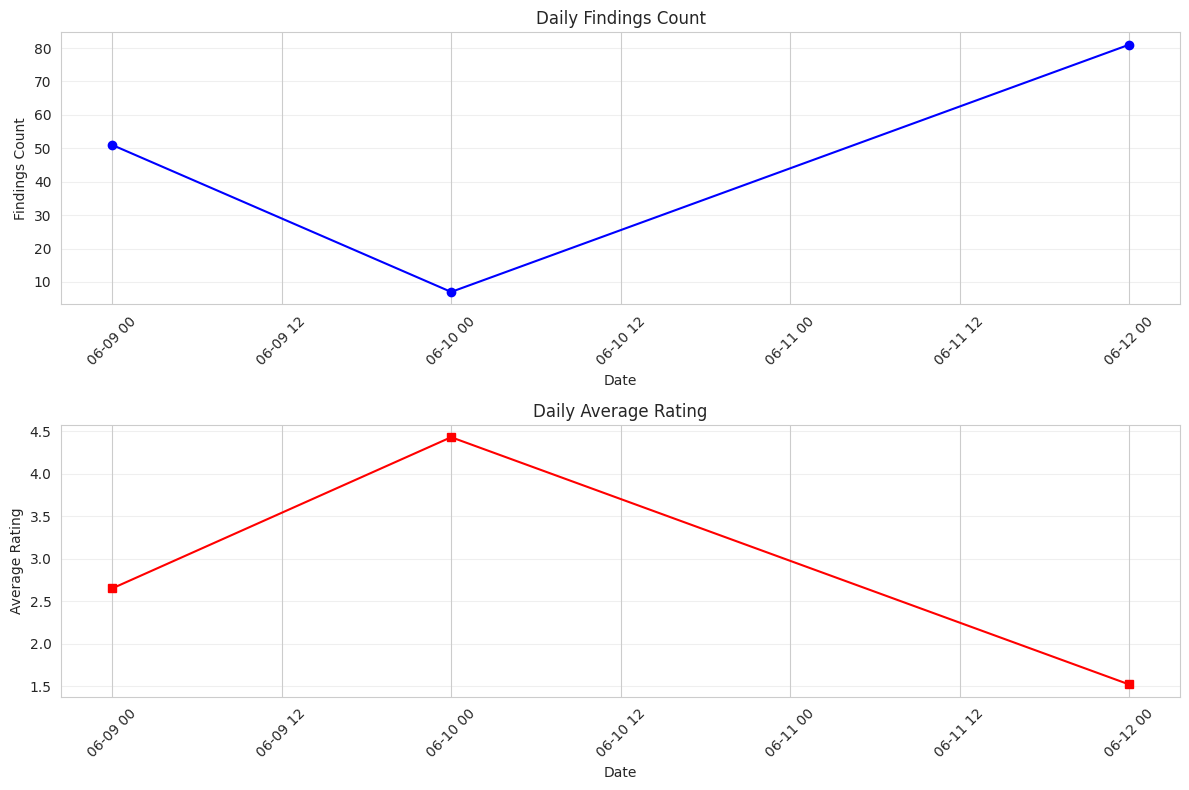

In [17]:
# Plot time series
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Daily count
daily_stats['count'].plot(kind='line', ax=ax1, marker='o', color='blue')
ax1.set_xlabel('Date')
ax1.set_ylabel('Findings Count')
ax1.set_title('Daily Findings Count')
ax1.grid(axis='y', alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Daily average rating
daily_stats['avg_rating'].plot(kind='line', ax=ax2, marker='s', color='red')
ax2.set_xlabel('Date')
ax2.set_ylabel('Average Rating')
ax2.set_title('Daily Average Rating')
ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Summary Statistics

In [18]:
print("="*60)
print("REVIEW SCORES ANALYSIS SUMMARY")
print("="*60)
print(f"\nTotal Findings: {len(df)}")
print(f"Date Range: {df['timestamp'].min().date()} to {df['timestamp'].max().date()}")
print(f"\nRating Statistics:")
print(f"  - Mean: {df['master_rating'].mean():.2f}")
print(f"  - Median: {df['master_rating'].median():.2f}")
print(f"  - Std Dev: {df['master_rating'].std():.2f}")
print(f"\nHigh-Value Findings (rating >= 4): {len(df[df['master_rating'] >= 4])} ({100*len(df[df['master_rating'] >= 4])/len(df):.1f}%)")
print(f"Low-Value Findings (rating <= 1): {len(df[df['master_rating'] <= 1])} ({100*len(df[df['master_rating'] <= 1])/len(df):.1f}%)")
print(f"\nUnique Tools: {df['tool_name'].nunique()}")
print(f"Unique Evaluators: {df['evaluator_id'].nunique()}")
print(f"Unique PRs: {df['pr_number'].nunique()}")
print(f"\nAverage Detection Latency: {df['detection_latency_ms'].mean()/1000:.2f} seconds")
print(f"\nTop Performing Tool (by avg rating): {tool_stats.index[0]} ({tool_stats['avg_rating'].iloc[0]:.2f})")
print(f"Most Active PR: PR #{pr_stats.index[0]} ({pr_stats['total_findings'].iloc[0]} findings)")

REVIEW SCORES ANALYSIS SUMMARY

Total Findings: 139
Date Range: 2026-06-09 to 2026-06-12

Rating Statistics:
  - Mean: 2.08
  - Median: 2.00
  - Std Dev: 1.63

High-Value Findings (rating >= 4): 34 (24.5%)
Low-Value Findings (rating <= 1): 58 (41.7%)

Unique Tools: 18
Unique Evaluators: 4
Unique PRs: 5

Average Detection Latency: 29.96 seconds

Top Performing Tool (by avg rating): kilo-code-bot[bot] (5.00)
Most Active PR: PR #88 (7 findings)
